<a href="https://colab.research.google.com/github/Roua-Elayeb/Conception-de-Robots-Intelligents-avec-NVIDIA-Jetson/blob/main/binary-classifier-ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print(sigmoid(0))
print(sigmoid(10))
print(sigmoid(-10))

0.5
0.9999546021312976
4.5397868702434395e-05


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv"
df = pd.read_csv(url)

features = ['CreditScore','Age','Tenure','Balance',
            'Num Of Products','Has Credit Card',
            'Is Active Member','Estimated Salary']

X = df[features].iloc[0].values
y_true = df['Churn'].iloc[0]

W = np.array([0.1, -0.3, 0.05, 0.2, -0.1, 0.15, 0.25, -0.05])
b = -0.2

z = np.dot(X, W) + b
y_pred = sigmoid(z)

print("z =", z)
print("Prediction =", y_pred)

if y_pred > 0.5:
    print("Client va quitter la banque")
else:
    print("Client reste dans la banque")

z = -5017.944
Prediction = 0.0
Client reste dans la banque


/tmp/ipykernel_39843/4161754111.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [ ]:
mse = (y_true - y_pred)**2
print("True value =", y_true)
print("MSE =", mse)

True value = 1
MSE = 1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['CreditScore','Age','Tenure','Balance',
        'Num Of Products','Has Credit Card',
        'Is Active Member','Estimated Salary']]

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7506 - loss: 0.5388 - val_accuracy: 0.7987 - val_loss: 0.4577
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7989 - loss: 0.4522 - val_accuracy: 0.8100 - val_loss: 0.4307
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8184 - loss: 0.4268 - val_accuracy: 0.8288 - val_loss: 0.4138
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8384 - loss: 0.4072 - val_accuracy: 0.8394 - val_loss: 0.3971
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8464 - loss: 0.3890 - val_accuracy: 0.8475 - val_loss: 0.3827
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8506 - loss: 0.3772 - val_accuracy: 0.8537 - val_loss: 0.3738
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8552 - loss: 0.3697 - val_accuracy: 0.8531 - val_loss: 0.3688
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8552 - loss: 0.3657 - val_accu

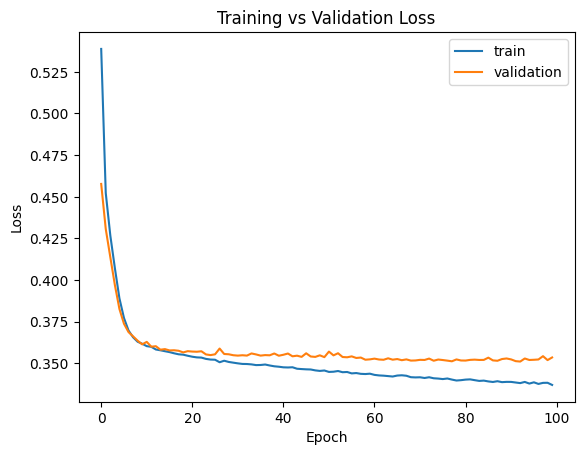

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train','validation'])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy =", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8540 - loss: 0.3609
Test Accuracy = 0.8539999723434448


In [ ]:
# Overfitting apparaît lorsque la loss d'entraînement diminue
# tandis que la validation loss augmente.

In [ ]:
# Binary crossentropy est utilisée pour les problèmes
# de classification binaire avec une sortie sigmoid.

In [ ]:
# Sans normalisation, certaines features ont des valeurs
# très grandes ce qui peut ralentir l'apprentissage
# et réduire la performance du modèle.